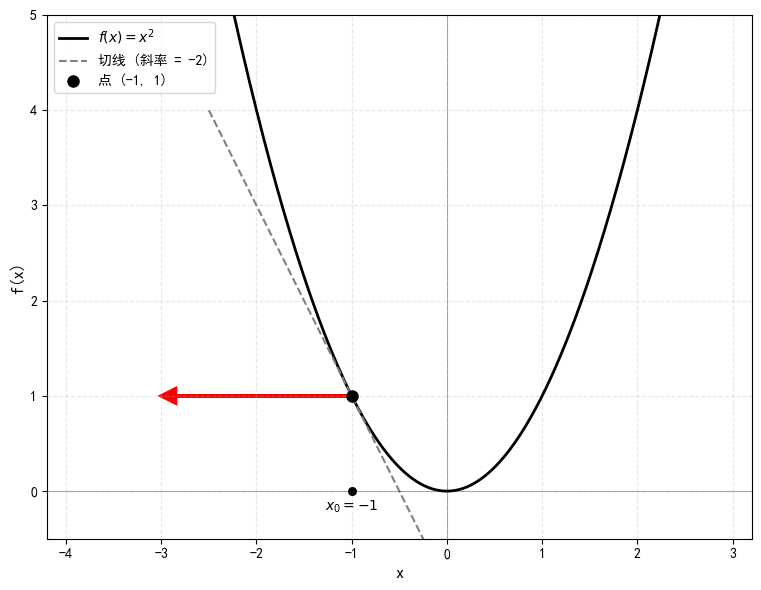

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数和导数
def f(x):
    return x**2

def df(x):
    return 2*x

# 数据
x = np.linspace(-4, 3, 400)
y = f(x)

# 选定点
x0 = -1
y0 = f(x0)  # = 1
slope = df(x0)  # = -2

# 创建图形
fig, ax = plt.subplots(figsize=(10, 6))

# 1. 画函数曲线
ax.plot(x, y, 'black', linewidth=2, label=r'$f(x) = x^2$')

# 2. 画出切线（斜率 = -2）
tangent_x = np.linspace(x0 - 1.5, x0 + 0.8, 100)
tangent_y = y0 + slope * (tangent_x - x0)
ax.plot(tangent_x, tangent_y, 'gray', linestyle='--', linewidth=1.5, label='切线 (斜率 = -2)')

# 3. 标注点 (-1, 1)
ax.plot(x0, y0, 'ko', markersize=8, label=f'点 ({x0}, {y0})')

# ==================== 关键修改：从 (-1, 1) 到 (-3, 1) 的射线 ====================
# 梯度向量：从 (-1, 1) 出发,指向 (-1-2, 1) = (-3, 1)
# 向量的分量：(-2, 0)
ax.arrow(x0, y0, -2, 0,
         head_width=0.15,
         head_length=0.15,
         fc='red',
         ec='red',
         linewidth=2.5,
         length_includes_head=True
        )

# 4. 标记终点 (-3, 1)


# 5. 添加辅助元素
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# 在 x 轴上标记 -1 和 -2
ax.scatter([-1], [0], color='black', s=30, zorder=5)
ax.text(-1, -0.2, r'$x_0=-1$', ha='center', fontsize=10)

# 6. 图框装饰
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(-4.2, 3.2)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

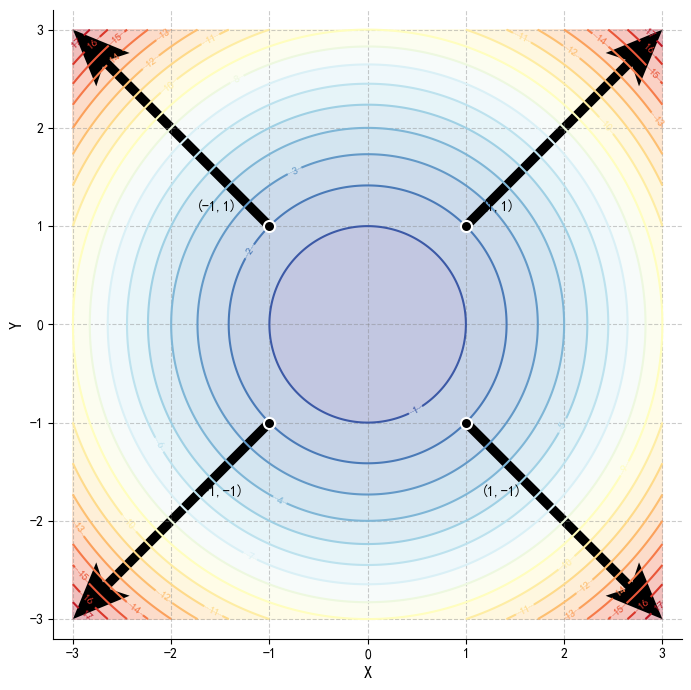

In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 1. 定义网格范围
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

# 2. 定义函数 z = x^2 + y^2
Z = X**2 + Y**2

# 3. 创建图形
plt.figure(figsize=(8, 7))

# 4. 绘制等高线（选择 20 条等高线）
contour = plt.contour(X, Y, Z, levels=20, cmap='RdYlBu_r')
plt.clabel(contour, inline=True, fontsize=8, fmt='%d')  # 标注数值

# 5. 可选：添加颜色填充（让高低更直观）
plt.contourf(X, Y, Z, levels=20, cmap='RdYlBu_r', alpha=0.3)

# ==================== 6. 在特定点绘制梯度向量 ====================
# 选取四个对称点,分布在四个象限
points = [(1, 1), (-1, 1), (1, -1), (-1, -1)]

# 定义梯度函数（便于后续修改函数时复用）
def gradient(x, y):
    """计算 f(x,y) = x^2 + y^2 的梯度向量"""
    return (2*x, 2*y)

# 为每个点绘制梯度箭头
for (px, py) in points:
    gx, gy = gradient(px, py)

    # 绘制梯度箭头（从点出发）- 纯黑色
    plt.quiver(px, py, gx, gy,
               angles='xy', scale_units='xy', scale=1,
               color='black',          # 纯黑色箭头
               width=0.015,            # 箭头杆稍粗
               headwidth=5,            # 箭头头宽度
               headlength=6,           # 箭头头长度
               headaxislength=5)       # 箭头头轴线长度

    # 标记点的位置（纯黑圆点）
    plt.plot(px, py, 'o',
             markersize=8,
             color='black',
             markeredgecolor='white',  # 白色描边,避免与等高线重叠看不清
             markeredgewidth=1.5,
             zorder=5)                 # 确保点显示在最上层

    # 添加坐标标签（根据象限调整位置,避免遮挡）
    offset_x = 0.15 if px >= 0 else -0.15 - 0.6
    offset_y = 0.15 if py >= 0 else -0.15 - 0.6
    plt.text(px + offset_x, py + offset_y,
             f'({px},{py})',
             fontsize=10,
             fontweight='bold',
             color='black')

# ==================== 7. 添加图框装饰（黑白版） ====================
plt.xlabel('X', fontsize=12, fontweight='medium')
plt.ylabel('Y', fontsize=12, fontweight='medium')
plt.title(r'等高线图: $z = x^2 + y^2$ 及其梯度向量',
          fontsize=14,
          fontweight='bold',
          pad=15)

# 网格线（浅灰色虚线）
plt.grid(alpha=0.4, linestyle='--', linewidth=0.8, color='gray')

# 保证坐标轴等比例（梯度垂直的关键）
plt.axis('equal')
plt.xlim(-3.2, 3.2)  # 稍微扩展边界,避免箭头被裁剪
plt.ylim(-3.2, 3.2)

# ==================== 添加图例（黑白风格） ====================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='black', markersize=8,
           label='P(i,j)'),
    Line2D([0], [0], color='black', linewidth=2,
           label='梯度向量（上升方向）'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=0.8,
           label='网格线')
]
plt.legend(handles=legend_elements,
           loc='upper right',
           frameon=True,
           framealpha=0.9,
           edgecolor='black',
           fontsize=9)

# 边框设置（简洁风格）
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
plt.axis('scaled')
plt.xlim(-3.2, 3.2)
plt.ylim(-3.2, 3.2)
plt.tight_layout()
plt.show()


